## Project Overview
This notebook explores clustering of processed customer support tickets using different text representation methods. The goal is to identify meaningful groups of issues and compare the effectiveness of TF-IDF and sentence embedding approaches. 
The main pipelines implemented in this notebook:
- TF-IDF with K-Means clustering
- Sentence embeddings with K-Means clustering

In [1]:
# Necessary libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

In [2]:
# Load processed data
df = pd.read_csv("cleaned_data.csv")
print(df.head())


   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [3]:
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'text', 'clean_text', 'processed_text']


In [4]:
# convert the text column to a standard list
ticket_list = df['processed_text'].tolist()
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'text', 'clean_text', 'processed_text']


In [5]:
# convert the text column to a standard list
ticket_list = df['processed_text'].tolist()
print(df.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'text', 'clean_text', 'processed_text']


# Analytics Axis 1: TF-IDF + K-Means

## Text Vectorisation
The preprocessed data will be converted into a numerical format using IF-IDF vectorisation. This allows for processing the text data by representing each document as a vector of features.
### Hypothesis
TF-IDF will be good at finding clustering based on exact keywords like password, but will fail to group semantically similar but differently worded tickets.

In [6]:
# Vectorise cleaned text
tfidf = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.5, ngram_range=(1,2))
# Handle missing data to prevent vectorization errors
tfidf_matrix = tfidf.fit_transform(df['processed_text'].fillna(''))

In [7]:
#K-Means 
km_tfidf = KMeans(n_clusters=10, random_state=42)
df['cluster_tfidf'] = km_tfidf.fit_predict(tfidf_matrix)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text,clean_text,processed_text,cluster_tfidf
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,I'm having an issue with the {product_purchase...,having issue with the please assist\n\nyour...,billing zip code appreciate requested website ...,4
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,I'm having an issue with the {product_purchase...,having issue with the please assist\n\n you...,existing product intermittent unexpectedly,2
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,I'm facing a problem with my {product_purchase...,facing problem with the not turning wa...,turning yesterday respond really charger came ...,2
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,I'm having an issue with the {product_purchase...,having issue with the please assist\n\n you...,youre interested love see feedback unresolved,2
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,...,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,I'm having an issue with the {product_purchase...,having issue with the please assist\n\n\nno...,seller responsible damage arising delivery bat...,2


In [8]:
print(df['cluster_tfidf'].value_counts())

cluster_tfidf
2    3519
1     774
8     719
7     685
4     621
5     484
3     389
0     374
6     326
9     186
Name: count, dtype: int64


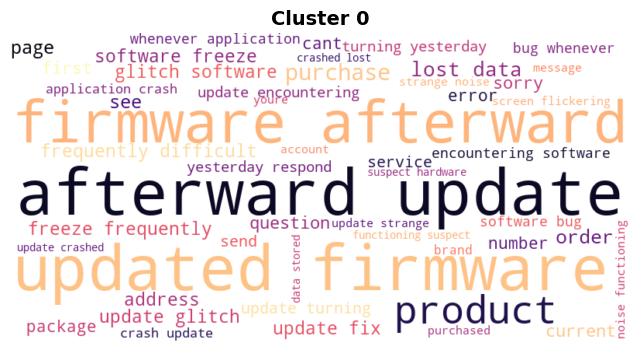

Cluster 0 - Top 10 words:
update:394
afterward:373
updated:372
firmware:368
product:133
software:29
purchase:22
fix:21
data:21
bug:19



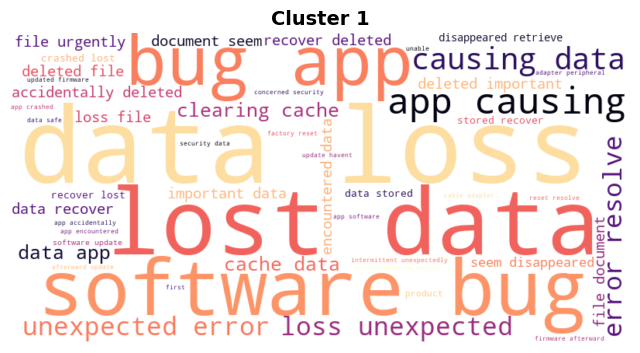

Cluster 1 - Top 10 words:
data:1065
app:396
file:356
loss:350
deleted:342
recover:307
lost:264
software:258
resolve:240
error:202



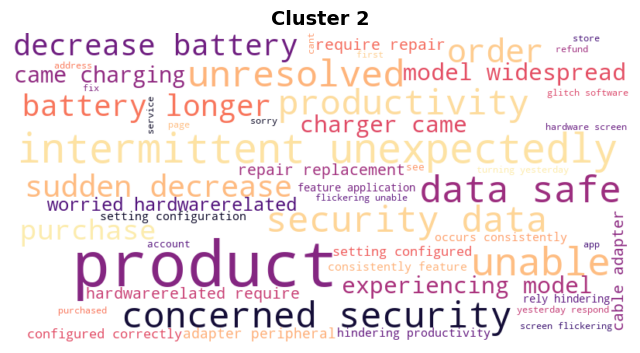

Cluster 2 - Top 10 words:
product:1425
productivity:505
unable:461
intermittent:370
unexpectedly:370
setting:350
data:348
unresolved:330
safe:324
security:315



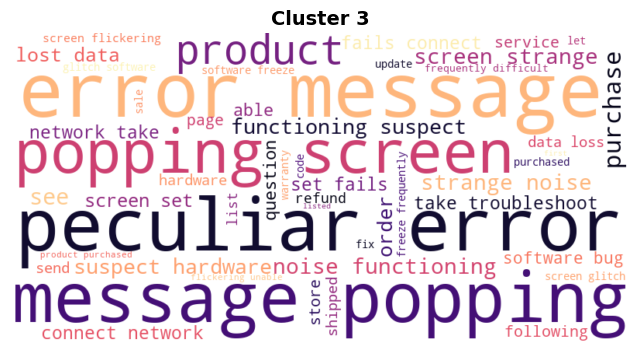

Cluster 3 - Top 10 words:
error:409
screen:403
message:398
peculiar:386
popping:386
product:150
data:36
hardware:30
account:28
software:25



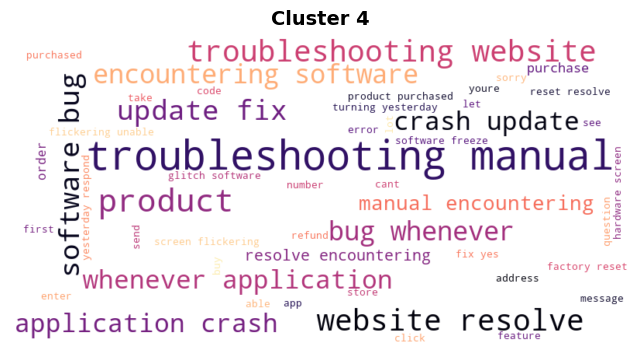

Cluster 4 - Top 10 words:
troubleshooting:491
manual:331
product:200
update:192
resolve:188
fix:169
software:166
website:163
bug:156
application:151



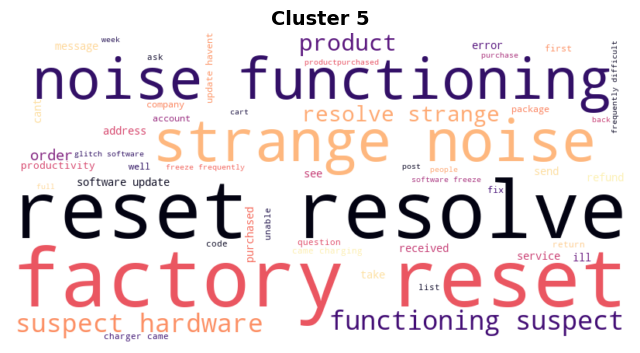

Cluster 5 - Top 10 words:
resolve:350
reset:343
factory:341
hardware:164
strange:158
noise:157
functioning:154
suspect:152
product:127
order:38



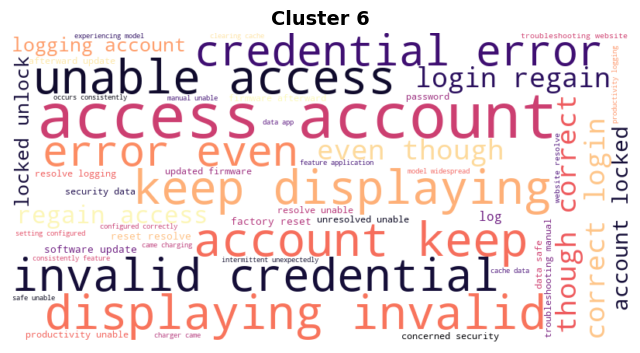

Cluster 6 - Top 10 words:
account:746
access:370
unable:205
login:195
error:191
correct:184
regain:184
keep:183
displaying:183
invalid:183



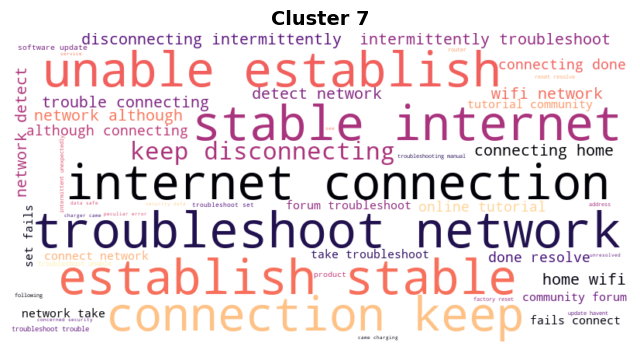

Cluster 7 - Top 10 words:
network:773
troubleshoot:535
connecting:362
resolve:235
unable:230
connection:206
internet:203
stable:190
set:188
connect:188



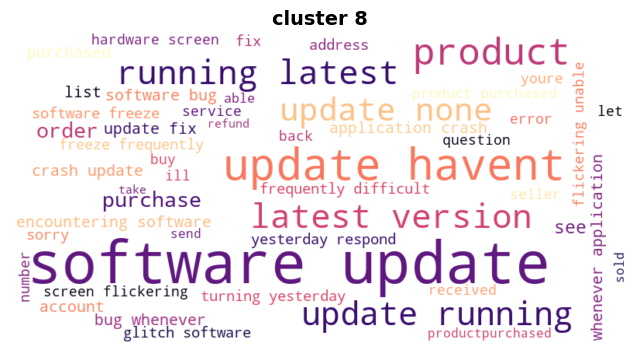

Cluster 8 - Top 10 words:
software:761
update:757
havent:350
product:272
version:206
running:198
latest:195
none:176
order:53
purchase:53



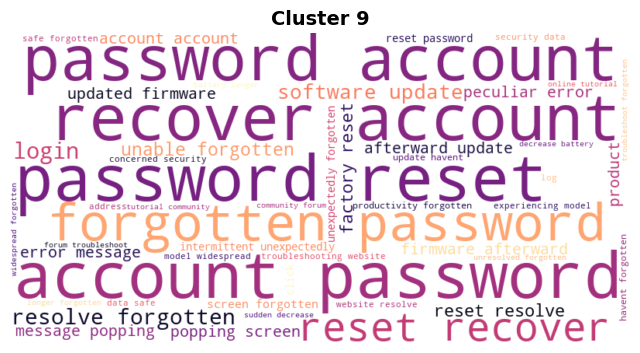

Cluster 9 - Top 10 words:
account:452
password:442
reset:229
recover:214
forgotten:188
update:34
login:24
resolve:24
software:19
unable:15



In [9]:
# Wordclouds for each cluster
topic_mapping = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
    4: "Cluster 4",
    5: "Cluster 5",
    6: "Cluster 6",
    7: "Cluster 7",
    8: "cluster 8",
    9: "Cluster 9"
}
df['topic_label'] = df['cluster_tfidf'].map(topic_mapping)
n_clusters = len(df['cluster_tfidf'].unique())
for i in range(n_clusters):
    cluster_text = " ".join(df[df['cluster_tfidf'] == i]['processed_text'].dropna().astype(str))
    #Split into words and count frequencies
    words = re.findall(r'\b[a-zA-Z]{3,}\b', cluster_text.lower()) 
    word_count = Counter(words)
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma', max_words=50).generate(" ".join(words))
    current_label = topic_mapping[i] 
    # Plot
    plt.figure(figsize=(8, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"{current_label}", fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()
        # Top 5 words
    top_words = word_count.most_common(10)
    print(f"Cluster {i} - Top 10 words:")
    for word, count in top_words:
        print(f"{word}:{count}")
    print()

k=2, Silhouette score: 0.0196
k=3, Silhouette score: 0.0268
k=4, Silhouette score: 0.0349
k=5, Silhouette score: 0.0438
k=6, Silhouette score: 0.0504
k=7, Silhouette score: 0.0586
k=8, Silhouette score: 0.0634
k=9, Silhouette score: 0.0691
k=10, Silhouette score: 0.0787


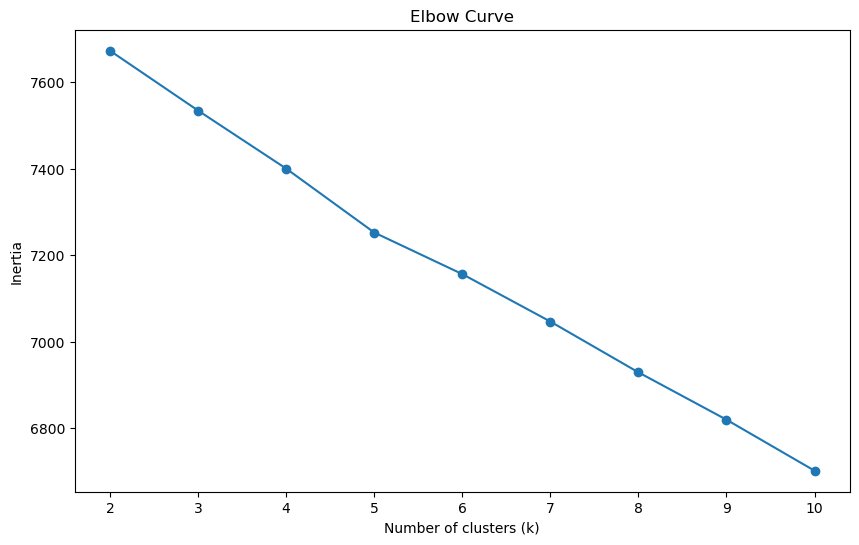

In [10]:
df['processed_text'] = df['processed_text'].fillna('')
tfidf_matrix = tfidf.fit_transform(df["processed_text"])
inertia = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_matrix)
    df['cluster_tfidf'] = labels
    # store inertia
    inertia.append (kmeans.inertia_)
    #silhouette score
    score = silhouette_score(tfidf_matrix, labels)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette score: {score:.4f}")
# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

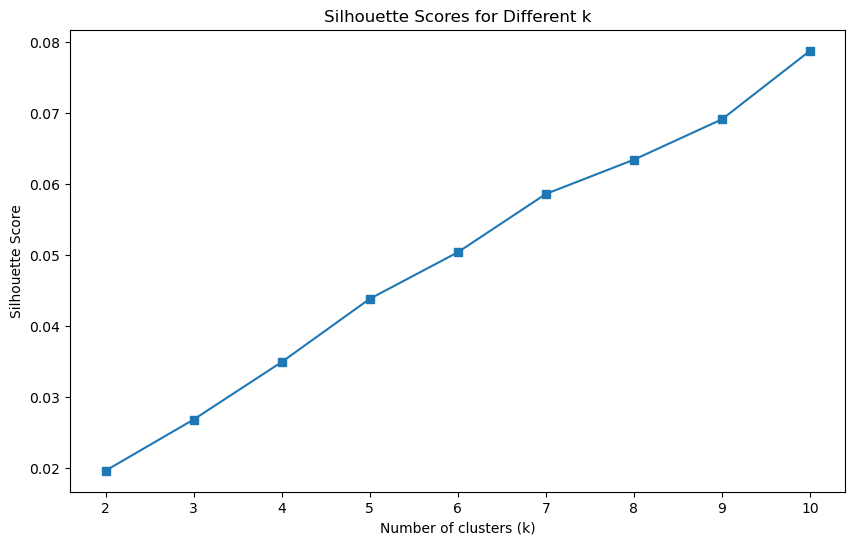

In [11]:

# plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different k')
plt.show()

## TF-IDF Clustering Evaluation
The elbow curve exhibits a linear decay rather than an obvious elbow point, suggesting that there is no optimal number of clusters based solely on inertia. This is because the improvement in compactness is incremental rather than significant at any specific value of k. Similarly, across all k values, the silhouette scores are relatively low and increase gradually from 0.0196 at k=2 to 0.0787 at k=10. This suggests weak cluster separation and indicates that, as the number of clusters increases, the finer partitioning of the data yields rather than meaningful improvements in cluster quality. In spite of this weakness in the quantitative performance, qualitative analysis of clusters showed multiple meaningful groupings; as such, the distinct clusters emerge for software update issues (cluster 0 and 8), data loss and recovery (cluster 1), network connectivity issues (cluster 7) and account-related problems (clusters 6 and 9). However, between these clusters, there is a clear overlap; for example, several clusters relate to similar themes like updates in clusters 0 and 8 and account issues in clusters 6 and 9, which suggests a redundancy when the number of clusters is high. Additionally, some clusters, like cluster 2 and 4, contain more generic words such as "product" and "resolve", making them harder to interpret. 
Overall, with TF-IDF, the identification of some clear, keyword-driven issues within the dataset was possible. However, due to its reliance on word frequency rather than semantic meaning, it struggles to separate more abstract or overlapping concepts. 

In [12]:
%pip install sentence-transformers
%pip install --upgrade datasets transformers sentence-transformers

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


## Analytic Axis 2: Sentence Embeddings + K-Means

### Hypothesis
Sentence embeddings will capture nuance, context, and semantic meaning, leading to more human-intuitive clusters.  

In [33]:
from sentence_transformers import SentenceTransformer
def clean_for_embeddings(text):
    text = re.sub(r'http\S+', ' ', text)  # Remove URLs
    text = re.sub(r'\s+', ' ', text).strip() # Cleanup whitespace
    return text

# Apply cleaning and drop duplicates
df = df.drop_duplicates(subset=['Ticket Description'])
df['embedding_text'] = df['Ticket Description'].apply(clean_for_embeddings)


In [34]:
# Load the model
model = SentenceTransformer ('all-MiniLM-L6-v2')
embeddings = model.encode(df['embedding_text'].fillna('').tolist())
# Normalise the vectors
embeddings = normalize(embeddings)
km_embed = KMeans(n_clusters=7, random_state=42)
df['cluster_embed'] = km_embed.fit_predict(embeddings)
print(f"Loaded sentance-transformer model: '{model}'")

# Some example sentences for quality check
example_tickets = [
    "Password reset requested; I am locked out of my account.", # Account related
    "Login failed: system won't accept my sign-in details.",    # Account related
    "I've been double-billed for this month's plan.",           # Billing related
    "I need a PDF of my latest transaction receipt.",         #Billing related
    "Is it possible to include a CSV export option?"          # Requesting a new feature
]

# generate embeddings
example_embeddings = model.encode(example_tickets)
# check it works
from sklearn.metrics.pairwise import cosine_similarity
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[1]])
print(f"Test Similarity score for two accounts tickets: {sim[0][0]:.4f}")
sim = cosine_similarity([example_embeddings[0]], [example_embeddings[4]])
print(f"Test Similarity score for different tickets: {sim[0][0]:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded sentance-transformer model: 'SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)'
Test Similarity score for two accounts tickets: 0.5435
Test Similarity score for different tickets: -0.1041


In [26]:
# Process the dataset
df['embeddings'] = list(model.encode(df['embedding_text'].astype(str), show_progress_bar=True))
# Save the dataframe
df.to_csv('embedded_customer_support_tickets.csv', index=False)

Batches:   0%|          | 0/253 [00:00<?, ?it/s]

k=2 | Silhouette: 0.2197 | Inertia: 2765.08
k=3 | Silhouette: 0.2409 | Inertia: 2529.53
k=4 | Silhouette: 0.1952 | Inertia: 2369.11
k=5 | Silhouette: 0.1980 | Inertia: 2215.44
k=6 | Silhouette: 0.2058 | Inertia: 2106.85
k=7 | Silhouette: 0.1898 | Inertia: 2036.70
k=8 | Silhouette: 0.1818 | Inertia: 1951.79
k=9 | Silhouette: 0.1594 | Inertia: 1891.46
k=10 | Silhouette: 0.1645 | Inertia: 1837.54


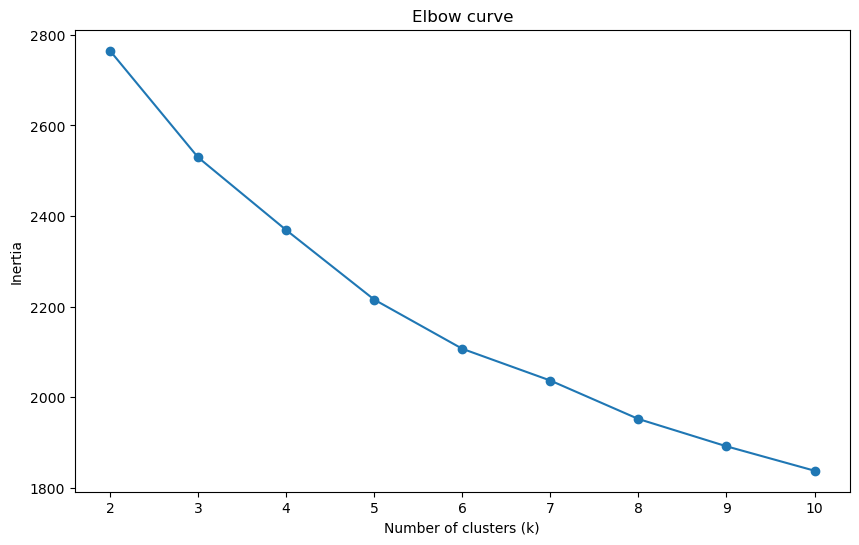

In [27]:
# convert the embedding list into 2D array for KMeans
x = np.stack(df['embeddings'].values)
# calculate inertia for K = 2 to 10
inertia = []
silhouette_scores = []
k_range = range(2 , 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    # Calculate and store Silhouette Score
    s_score = silhouette_score(x, cluster_labels)
    silhouette_scores.append(s_score)
    
    # Calculate and store Inertia
    inertia.append(kmeans.inertia_)
    print(f"k={k} | Silhouette: {s_score:.4f} | Inertia: {kmeans.inertia_:.2f}")

# plot Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow curve')
plt.show()    

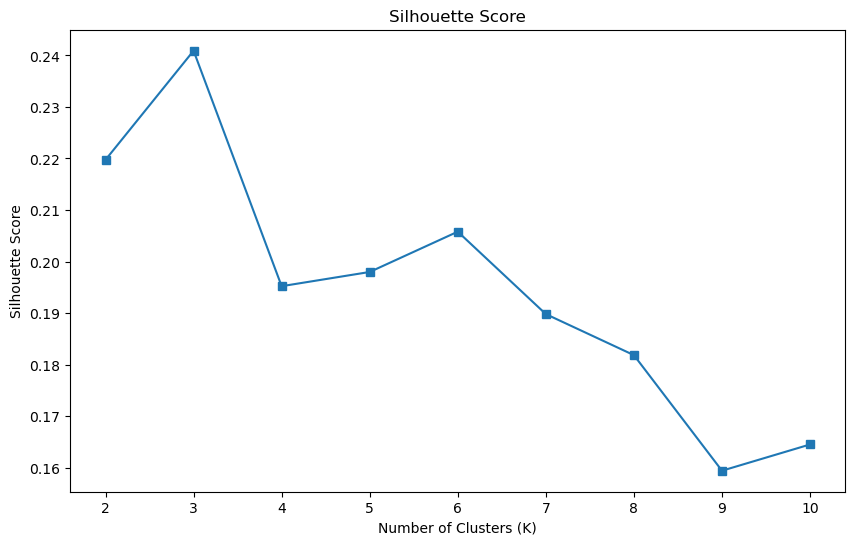

In [28]:
#plot Silhouette 
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='s')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()

## Sentence Embeddings Clustering Evaluation
Similar to the TF-IDF results, the elbow curve shows a consistent decrease in inertia as the number of clusters increases and no clear elbow point. This indicates that inertia alone does not provide an optimal value of k. However, the silhouette scores show a clearer trend than TF-IDF. The silhouette scores increased from 0.0431 at k=2 to 0.0910 at k=10, and are consistently higher than the scores using TF-IDF, suggesting that sentence embeddings produce better separated clusters overall. Nonetheless, having no clear peak with this gradual increase indicates that increasing k leads to finer partitioning rather than a strong optimal clustering.
When compared with TF-IDF, the higher silhouette scores suggest improved clustering quality. This is due to sentence embeddings capturing semantic relationships between words, which allows tickets with similar meanings but different wording to be grouped more effectively. Despite sentence embeddings having a better silhouette score, the absence of a sharp peak in silhouette scores indicates that the data does not naturally separate into a fixed number of well-defined clusters. In conclusion, sentence embeddings provide a more meaningful representation of the data than TF-IDF, resulting in better clusters and better interpretability. Yet, similar to TF-IDF, increasing the number of clusters increases the risk of over-segmentation and redundancy.  